# Dataset de Churn de usuários de serviços de telefonia

## Sobre o Conjunto de Dados
### Contexto 
Uma empresa fictícia de telecomunicações que forneceu serviços de telefonia fixa e internet para 7.043 clientes na Califórnia no terceiro trimestre. 

### Objetivo
Criar um modelo de machine learning para prever o churn de cliente no proximo mês.

### Descrição dos Dados 
7.043 observações com 33 variáveis 

**CustomerID**: Um ID único que identifica cada cliente.
 
**Count**: Um valor usado em relatórios e dashboards para somar o número de clientes em um conjunto filtrado.
 
**Country**: O país de residência principal do cliente.
 
**State**: O estado de residência principal do cliente.
 
**City**: A cidade de residência principal do cliente.
 
**Zip Code**: O CEP da residência principal do cliente.
 
**Lat Long**: A combinação de latitude e longitude da residência principal do cliente.
 
**Latitude**: A latitude da residência principal do cliente.
 
**Longitude**: A longitude da residência principal do cliente.
 
**Gender**: O gênero do cliente: Masculino, Feminino.
 
**Senior Citizen**: Indica se o cliente tem 65 anos ou mais: Sim, Não.
 
**Partner**: Indica se o cliente tem um parceiro(a): Sim, Não.
 
**Dependents**: Indica se o cliente mora com dependentes: Sim, Não. Dependentes podem ser filhos, pais, avós, etc.
 
**Tenure Months**: Indica o total de meses que o cliente está com a empresa até o final do trimestre especificado.
 
**Phone Service**: Indica se o cliente assina o serviço de telefone fixo da empresa: Sim, Não.
 
**Multiple Lines**: Indica se o cliente assina múltiplas linhas telefônicas com a empresa: Sim, Não.
 
**Internet Service**: Indica se o cliente assina o serviço de internet da empresa: Não, DSL, Fibra Óptica, Cabo.
 
**Online Security**: Indica se o cliente assina um serviço adicional de segurança online fornecido pela empresa: Sim, Não.
 
**Online Backup**: Indica se o cliente assina um serviço adicional de backup online fornecido pela empresa: Sim, Não.
 
**Device Protection**: Indica se o cliente assina um plano adicional de proteção de dispositivos para seus equipamentos de internet fornecido pela empresa: Sim, Não.
 
**Tech Support**: Indica se o cliente assina um plano adicional de suporte técnico da empresa com tempos de espera reduzidos: Sim, Não.
 
**Streaming TV**: Indica se o cliente utiliza seu serviço de internet para transmitir programação de televisão de um provedor terceiro: Sim, Não. A empresa não cobra taxa adicional por este serviço.
 
**Streaming Movies**: Indica se o cliente utiliza seu serviço de internet para transmitir filmes de um provedor terceiro: Sim, Não. A empresa não cobra taxa adicional por este serviço.
 
**Contract**: Indica o tipo de contrato atual do cliente: Mês a Mês, Um Ano, Dois Anos.
 
**Paperless Billing**: Indica se o cliente optou pela fatura sem papel (digital): Sim, Não.
 
**Payment Method**: Indica como o cliente paga sua fatura: Débito Bancário, Cartão de Crédito, Cheque pelos Correios.
 
**Monthly Charge**: Indica o valor mensal total atual do cliente por todos os seus serviços contratados.
 
**Total Charges**: Indica o total de cobranças do cliente, calculado até o final do trimestre especificado.
 
**Churn Label**: Sim = o cliente deixou a empresa neste trimestre. Não = o cliente permaneceu com a empresa. Diretamente relacionado ao Churn Value.
 
**Churn Value**: 1 = o cliente deixou a empresa neste trimestre. 0 = o cliente permaneceu com a empresa. Diretamente relacionado ao Churn Label.
 
**Churn Score**: Um valor de 0 a 100 calculado pela ferramenta preditiva IBM SPSS Modeler. O modelo incorpora múltiplos fatores conhecidos por causar churn. Quanto maior a pontuação, maior a probabilidade de o cliente cancelar.
 
**CLTV**: Customer Lifetime Value (Valor do Tempo de Vida do Cliente). O CLTV previsto é calculado usando fórmulas corporativas e dados existentes. Quanto maior o valor, mais valioso é o cliente. Clientes de alto valor devem ser monitorados quanto ao risco de churn.
 
**Churn Reason**: O motivo específico do cliente para deixar a empresa. Diretamente relacionado à Churn Category.

### Importação das bibliotecas

In [44]:
# Autoreload para refletir mudanças no config sem reiniciar kernel
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [45]:
# Basic imports
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

In [46]:
from churn_telecom.config import get_logger
logger = get_logger("0.01_data_source")

In [57]:
# Célula 3 — módulo interno do projeto
from churn_telecom.config import (
    COLS_CAT,
    COLS_NUM,
    COLS_POS,
    DATA_INTERIM,
    LABEL_COL,
    RANDOM_STATE,
    REPORTS_FIGURES,
    TARGET,
    MLFLOW_EXPERIMENT,
    MLFLOW_TRACKING_URI,
    setup_mlflow,
)

In [58]:
setup_mlflow()
logger.info("MLflow tracking URI : %s", MLFLOW_TRACKING_URI)
logger.info("MLflow experiment   : %s", MLFLOW_EXPERIMENT)

c:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\.venv\lib\site-packages\mlflow\tracking\_tracking_service\utils.py:184: FutureWarning: The filesystem tracking backend (e.g., './mlruns') is deprecated as of February 2026. Consider transitioning to a database backend (e.g., 'sqlite:///mlflow.db') to take advantage of the latest MLflow features. See https://mlflow.org/docs/latest/self-hosting/migrate-from-file-store for migration guidance.
  return FileStore(store_uri, store_uri)
2026/04/10 17:04:27 INFO mlflow.tracking.fluent: Experiment with name 'churn-telecom' does not exist. Creating a new experiment.
MLflow tracking URI : C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\mlruns
MLflow experiment   : churn-telecom


### Ingestão dos dados
Validação da leitura correta dos dados

In [48]:
df = pd.read_excel('../data/raw/raw_telco_customer_churn.xlsx')

logger.info("Shape: %s", df.shape)
logger.info("Colunas:\n%s", list(df.columns))

Shape: (7043, 33)
Colunas:
['CustomerID', 'Count', 'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude', 'Gender', 'Senior Citizen', 'Partner', 'Dependents', 'Tenure Months', 'Phone Service', 'Multiple Lines', 'Internet Service', 'Online Security', 'Online Backup', 'Device Protection', 'Tech Support', 'Streaming TV', 'Streaming Movies', 'Contract', 'Paperless Billing', 'Payment Method', 'Monthly Charges', 'Total Charges', 'Churn Label', 'Churn Value', 'Churn Score', 'CLTV', 'Churn Reason']


In [49]:
# Exibir as primeiras linhas do DataFrame
df.head(5)

,CustomerID,Count,Country,State,City,Zip Code,Lat Long,Latitude,Longitude,Gender,...,Contract,Paperless Billing,Payment Method,Monthly Charges,Total Charges,Churn Label,Churn Value,Churn Score,CLTV,Churn Reason
0,3668-QPYBK,1,United States,California,Los Angeles,90003,"33.964131, -118.272783",33.964131,-118.272783,Male,...,Month-to-month,Yes,Mailed check,53.85,108.15,Yes,1,86,3239,Competitor made better offer
1,9237-HQITU,1,United States,California,Los Angeles,90005,"34.059281, -118.30742",34.059281,-118.307420,Female,...,Month-to-month,Yes,Electronic check,70.70,151.65,Yes,1,67,2701,Moved
2,9305-CDSKC,1,United States,California,Los Angeles,90006,"34.048013, -118.293953",34.048013,-118.293953,Female,...,Month-to-month,Yes,Electronic check,99.65,820.5,Yes,1,86,5372,Moved
3,7892-POOKP,1,United States,California,Los Angeles,90010,"34.062125, -118.315709",34.062125,-118.315709,Female,...,Month-to-month,Yes,Electronic check,104.80,3046.05,Yes,1,84,5003,Moved
4,0280-XJGEX,1,United States,California,Los Angeles,90015,"34.039224, -118.266293",34.039224,-118.266293,Male,...,Month-to-month,Yes,Bank transfer (automatic),103.70,5036.3,Yes,1,89,5340,Competitor had better devices


### Verficiação dos tipos das features

In [50]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 33 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   CustomerID         7043 non-null   object 
 1   Count              7043 non-null   int64  
 2   Country            7043 non-null   object 
 3   State              7043 non-null   object 
 4   City               7043 non-null   object 
 5   Zip Code           7043 non-null   int64  
 6   Lat Long           7043 non-null   object 
 7   Latitude           7043 non-null   float64
 8   Longitude          7043 non-null   float64
 9   Gender             7043 non-null   object 
 10  Senior Citizen     7043 non-null   object 
 11  Partner            7043 non-null   object 
 12  Dependents         7043 non-null   object 
 13  Tenure Months      7043 non-null   int64  
 14  Phone Service      7043 non-null   object 
 15  Multiple Lines     7043 non-null   object 
 16  Internet Service   7043 

Obs: Foi identificado que a feature "Total Charges" veio como string, sendo na verdade do tipo float, impossibilitando contar os valores faltantes como NaN.



In [51]:
# Correção de tipo: Total Charges veio como string
df['Total Charges'] = pd.to_numeric(df['Total Charges'], errors='coerce')
logger.info("Conversão da coluna 'Total Charges' de string (object) para numérica realizada.")

Conversão da coluna 'Total Charges' de string (object) para numérica realizada.


### Tipos de features presentes no Dataset

In [52]:
RANDOM_STATE = 42

# ── Identificadores e geo — nunca usar como features ──────────────────────────
cols_id = [
    'CustomerID', 'Count',
    'Country', 'State', 'City', 'Zip Code', 'Lat Long', 'Latitude', 'Longitude',
]

# ── Features pré-cancelamento — candidatas ao modelo ──────────────────────────
cols_num = [
    'Tenure Months',
    'Monthly Charges',
    'Total Charges',
]

cols_cat = [
    'Gender', 'Senior Citizen', 'Partner', 'Dependents',
    'Phone Service', 'Multiple Lines', 'Internet Service',
    'Online Security', 'Online Backup', 'Device Protection',
    'Tech Support', 'Streaming TV', 'Streaming Movies',
    'Contract', 'Paperless Billing', 'Payment Method',
]

# ── Pós-cancelamento — DATA LEAKAGE: jamais usar como features ────────────────
cols_pos = [
    'Churn Score',    # score calculado pelo IBM SPSS após o evento
    'CLTV',           # calculado com dados do cliente já encerrado
    'Churn Reason',   # motivo registrado só depois do cancelamento
]

# ── Target ────────────────────────────────────────────────────────────────────
target    = 'Churn Value'   # 0 = ficou, 1 = saiu  ← usar na modelagem
label_col = 'Churn Label'   # 'Yes' / 'No'         ← apenas para leitura humana

# Validação de cobertura — garante que nenhuma coluna ficou de fora ou duplicada
all_defined = set(cols_id + cols_num + cols_cat + cols_pos + [target, label_col])
all_columns = set(df.columns)

missing  = all_columns - all_defined
orphans  = all_defined - all_columns

logger.info("Colunas não categorizadas : %s", missing)
logger.info("Colunas categorizadas ausentes no df: %s", orphans)

assert not missing, f"Categorize as colunas: {missing}"
assert not orphans, f"Colunas inexistentes no df: {orphans}"

logger.info("Colunas numéricas: %d", len(cols_num))
logger.info("Colunas categóricas: %d", len(cols_cat))
logger.info("Colunas de ID / Geo: %d", len(cols_id))

Colunas não categorizadas : set()
Colunas categorizadas ausentes no df: set()
Colunas numéricas: 3
Colunas categóricas: 16
Colunas de ID / Geo: 9


**Este conjunto de dados contém informações de 7.043 clientes, estruturadas em variáveis que permitem uma análise multidimensional do ciclo de vida do usuário. Sendo categorizados em quatro eixos:**

- Identificação e Localização: Colunas como CustomerID, City, Zip Code e coordenadas geográficas (Lat Long) fornecem o contexto espacial, mas são removidas do treinamento para evitar overfitting e garantir a generalização do modelo.

- Perfil e Fidelidade: Atributos demográficos (Gender, Senior Citizen, Partner, Dependents) e o tempo de permanência (Tenure Months) são cruciais para segmentar o risco.

- Portfólio de Serviços: Inclui o tipo de internet (Fiber Optic, DSL), serviços de segurança (Online Security) e entretenimento (Streaming TV), permitindo identificar quais produtos retêm ou afastam o cliente.

- Financeiro e Target: Variáveis como Monthly Charges, Total Charges, Contract e Payment Method representam a elasticidade de preço. O alvo principal é o Churn Value (0 ou 1), enquanto métricas como CLTV e Churn Score servem para a análise de viabilidade econômica e trade-off de custos do projeto.

### Observações sobre as categorias das features
- Churn Score e CLTV saem de cols_num. Ambas parecem numéricas inofensivas, mas são geradas por um modelo IBM que já sabe quem cancelou. Incluí-las seria vazar o futuro para o modelo — ele aprenderia a copiar o score em vez de aprender padrões reais de comportamento.
- Churn Reason sai de cols_cat. Só existe para clientes que já saíram, então teria 73% de nulos estruturais no treino — e seria nulo 100% das vezes em produção, onde você precisa prever antes do cancelamento.
target vs label_col separados explicitamente. 
- Churn Value (0/1) vai para o modelo; 
- Churn Label (Yes/No) fica apenas para inspeção humana. Essa distinção evita que alguém acidentalmente encode a string como feature categórica nos próximos notebooks.

### Validação de nulos e/ou duplicados

,Coluna,Qtd_Nulos,Pct_Nulos
Churn Reason,Churn Reason,5174,73.46
Total Charges,Total Charges,11,0.16


Nulos | Churn Reason | count=5174 | 73.46%
Nulos | Total Charges | count=11 | 0.16%


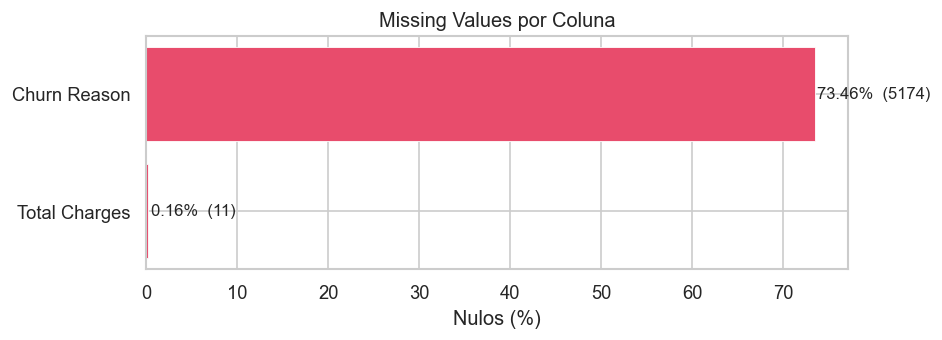

Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\missing_values.png


In [53]:
# ── Análise de valores ausentes ───────────────────────────────────────────────
# Constrói DataFrame com contagem e percentual de nulos por coluna
missing_values = pd.DataFrame({
    "Coluna":    df.columns,
    "Qtd_Nulos": df.isnull().sum(),
    "Pct_Nulos": (df.isnull().sum() / len(df) * 100).round(2),
})

# Filtra apenas colunas com nulos e ordena do mais crítico para o menos
missing_values = missing_values[missing_values["Qtd_Nulos"] > 0].sort_values(
    by="Pct_Nulos", ascending=False
)
display(missing_values)

if len(missing_values) > 0:
    # Altura dinâmica: evita gráfico achatado para muitas colunas
    fig, ax = plt.subplots(figsize=(8, max(3, len(missing_values) * 1.2)))

    ax.barh(
        missing_values["Coluna"],
        missing_values["Pct_Nulos"],
        color="#E84C6C",
        edgecolor="white",
        linewidth=0.5,
    )
    ax.set_xlabel("Nulos (%)")
    ax.set_title("Missing Values por Coluna")
    ax.invert_yaxis()  # coluna mais crítica no topo

    for i, (_, row) in enumerate(missing_values.iterrows()):
        # Anotação inline: exibe % e contagem absoluta na barra
        ax.text(
            row["Pct_Nulos"] + 0.3,
            i,
            f"{row['Pct_Nulos']}%  ({int(row['Qtd_Nulos'])})",
            va="center",
            fontsize=10,
        )
        logger.info(
            "Nulos | %s | count=%d | %.2f%%",
            row["Coluna"],
            int(row["Qtd_Nulos"]),
            row["Pct_Nulos"],
        )

    plt.tight_layout()
    output_path = REPORTS_FIGURES / "missing_values.png"
    plt.savefig(output_path, dpi=120, bbox_inches="tight")
    plt.show()
    plt.close()
    logger.info("Artefato salvo: %s", output_path)

else:
    logger.info("Nenhum missing value detectado no dataset.")

# Contexto de negócio dos nulos encontrados:
# - Churn Reason : 73.46% nulos — esperado, só clientes que cancelaram têm motivo registrado
# - Total Charges:  0.16% nulos — clientes com Tenure = 0 (recém-chegados, sem cobrança ainda)

In [54]:
# Valores duplicados
n_dup = df.duplicated().sum()
logger.info("Linhas duplicadas encontradas: %d", n_dup)  # Esperado: 0

Linhas duplicadas encontradas: 0


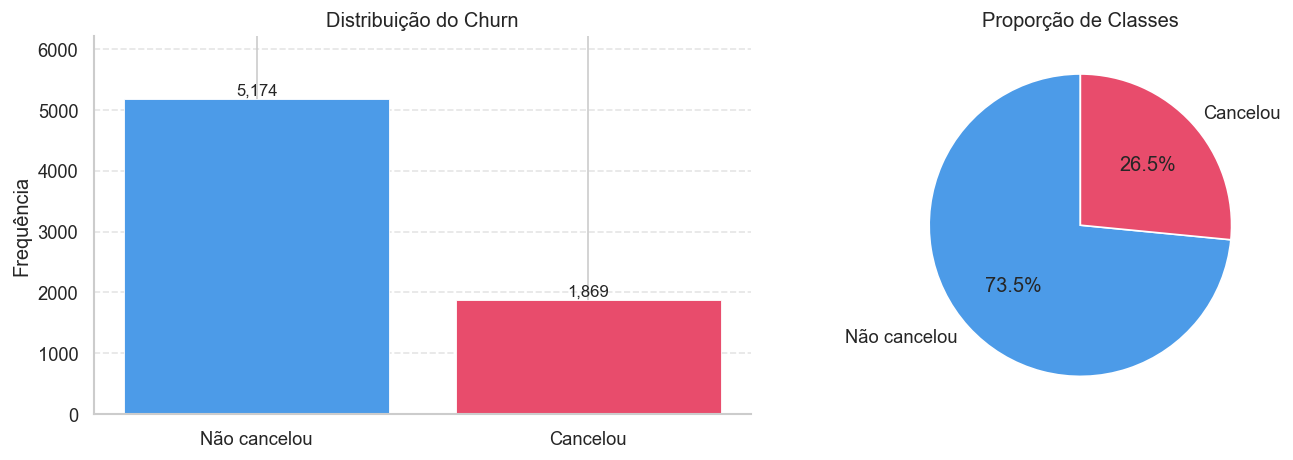

Artefato salvo: C:\Users\victo\Desktop\MLOPS\AULAS\tech_challenge_fase_1\projeto\reports\figures\churn_distribution.png
Target | Não cancelou (=0) | count=5174 | 73.46%
Target | Cancelou (=1) | count=1869 | 26.54%
Dataset desbalanceado (ratio=0.36) — usar class_weight='balanced' ou SMOTE na modelagem.


In [55]:
# ── Distribuição da variável target ───────────────────────────────────────────
target_counts = df[TARGET].value_counts()
target_pct    = df[TARGET].value_counts(normalize=True).mul(100).round(2)

# Labels legíveis para exibição nos gráficos
labels = {0: "Não cancelou", 1: "Cancelou"}

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ── Gráfico de barras — frequência absoluta ───────────────────────────────────
bar_labels = [labels[i] for i in target_counts.index]
bars = axes[0].bar(
    bar_labels,
    target_counts.values,
    color=["#4C9BE8", "#E84C6C"],
    edgecolor="white",
    linewidth=0.5,
    zorder=2,  # barras na frente do grid
)
# Contagem anotada no topo de cada barra
for bar, count, pct in zip(bars, target_counts.values, target_pct.values):
    axes[0].text(
        bar.get_x() + bar.get_width() / 2,
        bar.get_height() + 30,
        f"{count:,}",
        ha="center",
        va="bottom",
        fontsize=10,
    )
axes[0].set_ylabel("Frequência")
axes[0].set_title("Distribuição do Churn")
axes[0].set_ylim(0, target_counts.max() * 1.2)  # espaço para anotações
axes[0].yaxis.grid(True, linestyle="--", alpha=0.5, zorder=0)  # grid atrás das barras
axes[0].set_axisbelow(True)
axes[0].spines[["top", "right"]].set_visible(False)

# ── Gráfico de pizza — proporção de classes ───────────────────────────────────
axes[1].pie(
    target_counts.values,
    labels=[labels[i] for i in target_counts.index],
    autopct="%1.1f%%",
    colors=["#4C9BE8", "#E84C6C"],
    startangle=90,
)
axes[1].set_title("Proporção de Classes")

plt.tight_layout()
output_path = REPORTS_FIGURES / "churn_distribution.png"
plt.savefig(output_path, dpi=120, bbox_inches="tight")
plt.show()
plt.close()
logger.info("Artefato salvo: %s", output_path)

# Log por classe
for idx in target_counts.index:
    logger.info(
        "Target | %s (=%d) | count=%d | %.2f%%",
        labels[idx],
        idx,
        target_counts[idx],
        target_pct[idx],
    )

# Avalia desbalanceamento via ratio min/max
ratio = target_counts.min() / target_counts.max()
if ratio < 0.5:
    logger.warning(
        "Dataset desbalanceado (ratio=%.2f) — usar class_weight='balanced' ou SMOTE na modelagem.",
        ratio,
    )
else:
    logger.info("Dataset balanceado (ratio=%.2f).", ratio)

# Análise Inicial do Dataset — Data Understanding

## Dimensionalidade e Estrutura

O dataset contém 7.043 clientes e 33 variáveis brutas, reduzidas para 20 após a remoção de
identificadores, colunas geográficas e variáveis de leakage. A distribuição por tipo ficou:
3 numéricas (`Tenure Months`, `Monthly Charges`, `Total Charges`), 16 categóricas e 9 de
ID/Geo descartadas.

---

## Qualidade dos Dados

Dois problemas identificados:

`Total Charges` chegou como `object` no raw — convertida para `float64` via
`pd.to_numeric(errors='coerce')`, gerando 11 nulos (0.16%) correspondentes a clientes com
`Tenure Months = 0`, ou seja, recém-chegados sem nenhuma cobrança acumulada. Estratégia:
imputar com `0` no notebook `1.01-cleaning`, pois a ausência reflete um estado real do
negócio, não um dado faltante.

`Churn Reason` tem 73.46% de nulos (5.174 registros) — estruturalmente esperado, pois só
clientes que cancelaram têm motivo registrado. Essa coluna está isolada em `cols_pos` e não
entrará no modelo.

Zero duplicatas confirmado.

---

## Desbalanceamento de Classes

| Classe            | Contagem |    %  |
|-------------------|----------|-------|
| Não cancelou (0)  |   5.174  | 73.46% |
| Cancelou (1)      |   1.869  | 26.54% |
| **Ratio**         | **0.36** | —      |

O ratio de 0.36 confirma desbalanceamento moderado. Com ratio < 0.5 duas estratégias serão
avaliadas na modelagem:

- `class_weight='balanced'` nos modelos sklearn (Regressão Logística, baseline)
- `pos_weight` no `BCEWithLogitsLoss` do PyTorch (MLP)

SMOTE será avaliado como alternativa se as métricas de Recall ficarem insatisfatórias.

---

## Implicação Direta no Negócio

O desbalanceamento reflete a realidade operacional — a maioria dos clientes não cancela.
Isso torna o Recall da classe positiva (Cancelou=1) a métrica mais crítica:

- **Falso Negativo**: cliente que vai cancelar e não foi identificado → receita perdida
permanentemente.
- **Falso Positivo**: campanha de retenção desnecessária → custo controlável.

Essa assimetria de custos será formalizada no ML Canvas na próxima etapa.

---

## Próximos Passos

O dataset está íntegro e pronto para avançar. O `telco_typed.parquet` com shape `(7043, 20)`
é a entrada do `0.02-eda-univariate`, que analisará as distribuições individuais das
3 numéricas e 16 categóricas sem segmentação por target.

### Exportar os dados com tipos corrigidos para a proxima etapa:

In [56]:
# Colunas a descartar antes de salvar
cols_drop = cols_id + cols_pos + [label_col]

df_interim = df.drop(columns=cols_drop).copy()

# Dataset corrigido e tipado — pronto para as próximas etapas do pipeline
df_interim.to_parquet('../data/interim/telco_typed.parquet', index=False)
logger.info("Dataset salvo: data/interim/telco_typed.parquet — shape: %s", df_interim.shape)

Dataset salvo: data/interim/telco_typed.parquet — shape: (7043, 20)
